In [1]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("customer_churn_feature_engineered.csv")

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Tenure_Group,Monthly_Charge_Category,CLTV_Category,Total_Services,High_Value_Customer,Customer_Segment,Risk_Level,Revenue_Category,Customer_Age_Group,Customer_Status
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,0-12 Months,Medium,Low,3,No,Silver,High Risk,Low,Adult,Inactive
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,0-12 Months,High,Low,1,No,Standard,Medium Risk,Low,Adult,Inactive
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,0-12 Months,High,High,5,Yes,Premium,High Risk,Medium,Adult,Inactive
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,25-48 Months,High,Medium,6,Yes,Premium,High Risk,High,Adult,Inactive
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,49-72 Months,High,High,6,Yes,Premium,High Risk,High,Adult,Inactive


In [5]:
df.shape

(7043, 43)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               7043 non-null   object 
 1   Count                    7043 non-null   int64  
 2   Country                  7043 non-null   object 
 3   State                    7043 non-null   object 
 4   City                     7043 non-null   object 
 5   Zip_Code                 7043 non-null   int64  
 6   Lat_Long                 7043 non-null   object 
 7   Latitude                 7043 non-null   float64
 8   Longitude                7043 non-null   float64
 9   Gender                   7043 non-null   object 
 10  Senior_Citizen           7043 non-null   object 
 11  Partner                  7043 non-null   object 
 12  Dependents               7043 non-null   object 
 13  Tenure_Months            7043 non-null   int64  
 14  Phone_Service           

In [7]:
df.isnull().sum()

CustomerID                 0
Count                      0
Country                    0
State                      0
City                       0
Zip_Code                   0
Lat_Long                   0
Latitude                   0
Longitude                  0
Gender                     0
Senior_Citizen             0
Partner                    0
Dependents                 0
Tenure_Months              0
Phone_Service              0
Multiple_Lines             0
Internet_Service           0
Online_Security            0
Online_Backup              0
Device_Protection          0
Tech_Support               0
Streaming_TV               0
Streaming_Movies           0
Contract                   0
Paperless_Billing          0
Payment_Method             0
Monthly_Charges            0
Total_Charges              0
Churn_Label                0
Churn_Value                0
Churn_Score                0
CLTV                       0
Churn_Reason               0
Tenure_Group               0
Monthly_Charge

In [8]:
df = df.drop(
    columns=[
        "CustomerID",
        "Country",
        "State",
        "City",
        "Zip_Code",
        "Lat_Long",
        "Latitude",
        "Longitude",
        "Count",
        "Churn_Reason"
    ]
)

In [9]:
df.columns

Index(['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service',
       'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support',
       'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label',
       'Churn_Value', 'Churn_Score', 'CLTV', 'Tenure_Group',
       'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services',
       'High_Value_Customer', 'Customer_Segment', 'Risk_Level',
       'Revenue_Category', 'Customer_Age_Group', 'Customer_Status'],
      dtype='object')

In [10]:
X = df.drop("Churn_Value", axis=1)

y = df["Churn_Value"]

In [11]:
print(X.shape)
print(y.shape)

(7043, 32)
(7043,)


In [13]:
# Find all categorical columns
categorical_columns = X.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Churn_Label', 'Tenure_Group', 'Monthly_Charge_Category',
       'CLTV_Category', 'High_Value_Customer', 'Customer_Segment',
       'Risk_Level', 'Revenue_Category', 'Customer_Age_Group',
       'Customer_Status'],
      dtype='object')


In [14]:
le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [15]:
print(X.head())

   Gender  Senior_Citizen  Partner  Dependents  Tenure_Months  Phone_Service  \
0       1               0        0           0              2              1   
1       0               0        0           1              2              1   
2       0               0        0           1              8              1   
3       0               0        1           1             28              1   
4       1               0        0           1             49              1   

   Multiple_Lines  Internet_Service  Online_Security  Online_Backup  ...  \
0               0                 0                2              2  ...   
1               0                 1                0              0  ...   
2               2                 1                0              0  ...   
3               2                 1                0              0  ...   
4               2                 1                0              2  ...   

   Tenure_Group  Monthly_Charge_Category  CLTV_Category  Total

In [16]:
print(X.dtypes)

Gender                       int64
Senior_Citizen               int64
Partner                      int64
Dependents                   int64
Tenure_Months                int64
Phone_Service                int64
Multiple_Lines               int64
Internet_Service             int64
Online_Security              int64
Online_Backup                int64
Device_Protection            int64
Tech_Support                 int64
Streaming_TV                 int64
Streaming_Movies             int64
Contract                     int64
Paperless_Billing            int64
Payment_Method               int64
Monthly_Charges            float64
Total_Charges              float64
Churn_Label                  int64
Churn_Score                  int64
CLTV                         int64
Tenure_Group                 int64
Monthly_Charge_Category      int64
CLTV_Category                int64
Total_Services               int64
High_Value_Customer          int64
Customer_Segment             int64
Risk_Level          

In [17]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [18]:
type(X)

numpy.ndarray

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (5634, 32)
Testing Data : (1409, 32)


In [21]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
log_predictions = log_model.predict(X_test)

In [23]:
print("Accuracy :", accuracy_score(y_test, log_predictions))

Accuracy : 1.0


In [24]:
print("Precision :", precision_score(y_test, log_predictions))

Precision : 1.0


In [25]:
print("Recall :", recall_score(y_test, log_predictions))

Recall : 1.0


In [26]:
print("F1 Score :", f1_score(y_test, log_predictions))

F1 Score : 1.0


In [27]:
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [28]:
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1035
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [29]:
cm = confusion_matrix(y_test, log_predictions)

cm

array([[1035,    0],
       [   0,  374]])

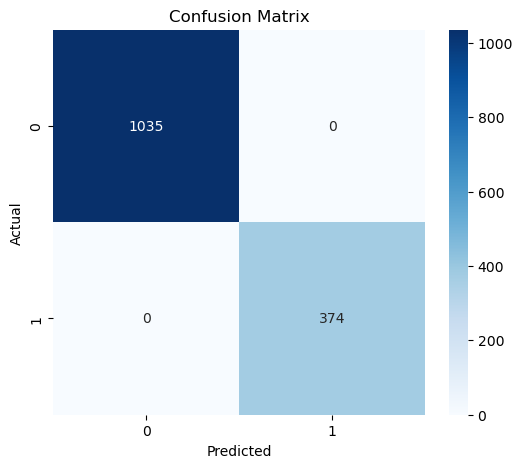

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

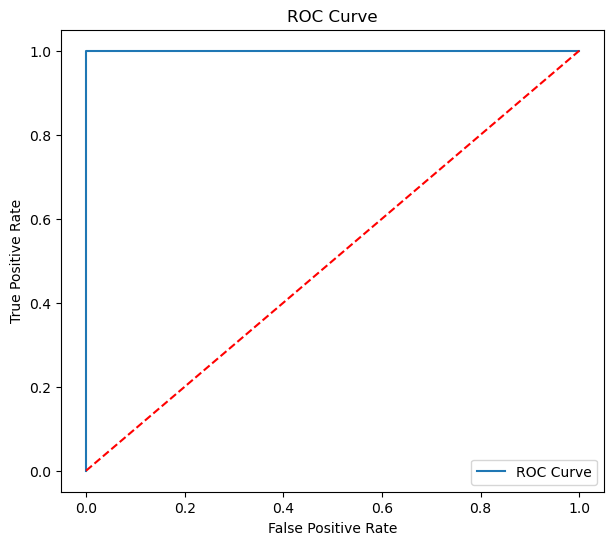

In [31]:
y_probability = log_model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_probability)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [32]:
roc = roc_auc_score(y_test, y_probability)

print("ROC AUC :", roc)

ROC AUC : 1.0


In [37]:
print(df.columns.tolist())

['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group', 'Customer_Status']


In [38]:
df = df.drop(
    columns=[
        "Churn_Label",
        "Churn_Score",
        "Customer_Status"
    ],
    errors="ignore"
)

In [39]:
print(df.columns.tolist())

['Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Value', 'CLTV', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group']


In [40]:
features = [
    "Gender",
    "Senior_Citizen",
    "Partner",
    "Dependents",
    "Tenure_Months",
    "Phone_Service",
    "Multiple_Lines",
    "Internet_Service",
    "Online_Security",
    "Online_Backup",
    "Device_Protection",
    "Tech_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Contract",
    "Paperless_Billing",
    "Payment_Method",
    "Monthly_Charges",
    "Total_Charges"
]

X = df[features]
y = df["Churn_Value"]

In [41]:
print(X.dtypes)

Gender                object
Senior_Citizen        object
Partner               object
Dependents            object
Tenure_Months          int64
Phone_Service         object
Multiple_Lines        object
Internet_Service      object
Online_Security       object
Online_Backup         object
Device_Protection     object
Tech_Support          object
Streaming_TV          object
Streaming_Movies      object
Contract              object
Paperless_Billing     object
Payment_Method        object
Monthly_Charges      float64
Total_Charges        float64
dtype: object


In [42]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col])

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
log_predictions = log_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, log_predictions))

Accuracy : 0.8034066713981547


In [48]:
from sklearn.metrics import precision_score

print("Precision :", precision_score(y_test, log_predictions))

Precision : 0.6430678466076696


In [49]:
from sklearn.metrics import recall_score

print("Recall :", recall_score(y_test, log_predictions))

Recall : 0.5828877005347594


In [50]:
from sklearn.metrics import f1_score

print("F1 Score :", f1_score(y_test, log_predictions))

F1 Score : 0.6115007012622721


In [51]:
from sklearn.metrics import roc_auc_score

print("ROC AUC :", roc_auc_score(y_test, log_predictions))

ROC AUC : 0.7329897439871865


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_predictions)

print(cm)

[[914 121]
 [156 218]]


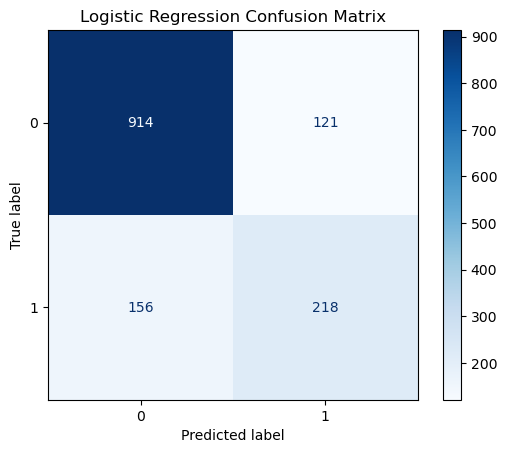

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



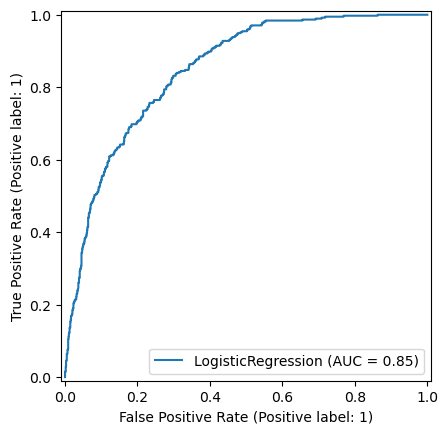

In [55]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test
)

plt.show()

In [56]:
importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": log_model.coef_[0]
    }
)

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(importance)

              Feature  Coefficient
17    Monthly_Charges     0.686663
18      Total_Charges     0.484436
15  Paperless_Billing     0.188401
7    Internet_Service     0.170811
2             Partner     0.152115
6      Multiple_Lines     0.099460
16     Payment_Method     0.093395
1      Senior_Citizen     0.017017
12       Streaming_TV     0.016398
13   Streaming_Movies     0.003046
0              Gender     0.002997
10  Device_Protection    -0.081125
9       Online_Backup    -0.119089
11       Tech_Support    -0.222722
8     Online_Security    -0.233614
5       Phone_Service    -0.287284
14           Contract    -0.604284
3          Dependents    -0.693834
4       Tenure_Months    -1.245863


In [57]:
importance.head(10)

,Feature,Coefficient
17,Monthly_Charges,0.686663
18,Total_Charges,0.484436
15,Paperless_Billing,0.188401
7,Internet_Service,0.170811
2,Partner,0.152115
6,Multiple_Lines,0.099460
16,Payment_Method,0.093395
1,Senior_Citizen,0.017017
12,Streaming_TV,0.016398
13,Streaming_Movies,0.003046


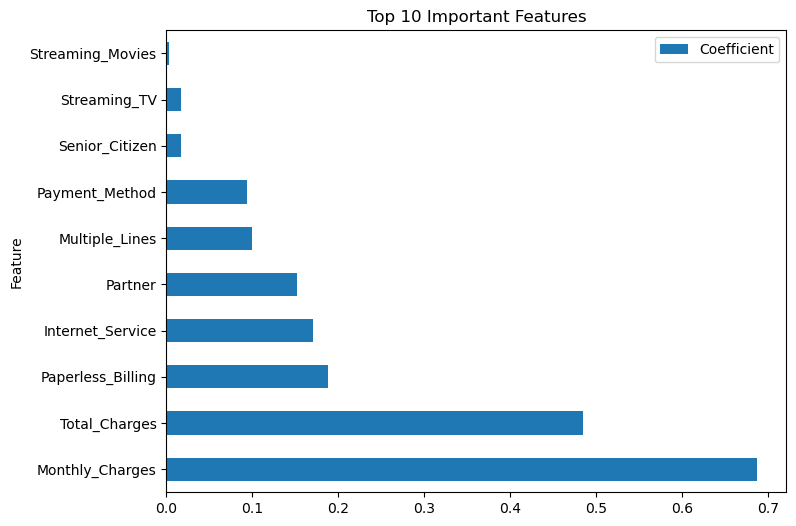

In [58]:
importance.head(10).plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Important Features")

plt.show()

In [59]:
predictions = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": log_predictions
    }
)

predictions.to_csv(
    "Customer_Churn_Predictions.csv",
    index=False
)

print("Predictions Saved Successfully!")

Predictions Saved Successfully!
